In [6]:
import gc
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from skrebate import ReliefF

# 1. Extract Data

In [7]:
path = kagglehub.dataset_download("lorentzyeung/price-paid-data-202304")
csv_file = os.path.join(path, "pp-complete.csv")


In [8]:
columns = [
    'Price', 'Date_of_Transfer', 'Postcode', 'Property_Type',
    'Old/New', 'Duration', 'PAON', 'SAON', 'Street',
    'Locality', 'Town/City', 'District', 'County',
    'PPD_Category_Type', 'Record_Status'
]

df = pd.read_csv(
    csv_file,
    names=columns,
    header=0,
)

print(df.head())
df.info()

   Price  Date_of_Transfer  Postcode Property_Type Old/New Duration PAON SAON  \
0  25000  1995-03-31 00:00   E16 1LG             F       N        L    9  NaN   
1  25500  1995-05-17 00:00   EN3 6EA             F       N        L   33  NaN   
2  42000  1995-04-21 00:00   N13 4RS             T       N        L   87  NaN   
3  43000  1995-06-30 00:00  RM10 7NU             T       N        F   45  NaN   
4   6500  1995-07-21 00:00  BB10 1BY             T       N        L   10  NaN   

           Street Locality Town/City              District          County  \
0   POLLARD CLOSE      NaN    LONDON                NEWHAM  GREATER LONDON   
1    BRIDLE CLOSE      NaN   ENFIELD               ENFIELD  GREATER LONDON   
2    RUSSELL ROAD      NaN    LONDON               ENFIELD  GREATER LONDON   
3   BOSWORTH ROAD      NaN  DAGENHAM  BARKING AND DAGENHAM  GREATER LONDON   
4  HURTLEY STREET      NaN   BURNLEY               BURNLEY      LANCASHIRE   

  PPD_Category_Type Record_Status  
0       

### Missing & Duplicate

In [8]:
missing_counts = {col: 0 for col in columns}
duplicate_counts = {col: 0 for col in columns}
total_rows = 0
seen_values = {col: set() for col in columns}

chunk_size = 500_000
for chunk in pd.read_csv(csv_file, names=columns, header=0, chunksize=chunk_size, dtype=str):
    total_rows += len(chunk)
    for col in columns:
        # Missing
        missing_counts[col] += chunk[col].isnull().sum()
        # Duplicate: nilai yang sudah pernah muncul sebelumnya
        duplicate_counts[col] += chunk[col].isin(seen_values[col]).sum()
        seen_values[col].update(chunk[col].dropna().unique())

# Buat tabel ringkas
summary = []
for col in columns:
    missing_pct = (missing_counts[col] / total_rows) * 100
    duplicate_pct = (duplicate_counts[col] / total_rows) * 100
    summary.append({
        'Fitur'              : col,
        'Total Baris'        : total_rows,
        'Missing Count'      : missing_counts[col],
        'Missing (%)'        : round(missing_pct, 2),
        'Duplicate Count'    : duplicate_counts[col],
        'Duplicate (%)'      : round(duplicate_pct, 2),
    })

df_summary = pd.DataFrame(summary)
print("=" * 60)
print("TABEL MISSING VALUE & DUPLICATE — SEMUA FITUR (15 KOLOM)")
print("=" * 60)
display(df_summary)

TABEL MISSING VALUE & DUPLICATE — SEMUA FITUR (15 KOLOM)


,Fitur,Total Baris,Missing Count,Missing (%),Duplicate Count,Duplicate (%)
0,Price,31270274,0,0.00,30468866,97.44
1,Date_of_Transfer,31270274,0,0.00,22676967,72.52
2,Postcode,31270274,50219,0.16,29130089,93.16
3,Property_Type,31270274,0,0.00,30770274,98.40
4,Old/New,31270274,0,0.00,30770274,98.40
5,Duration,31270274,0,0.00,30770274,98.40
6,PAON,31270274,4182,0.01,30078330,96.19
7,SAON,31270274,27530035,88.04,3630884,11.61
8,Street,31270274,497935,1.59,29891113,95.59
9,Locality,31270274,11935787,38.17,18833362,60.23


## Feature Selection

Correlation Matrix (Extended)

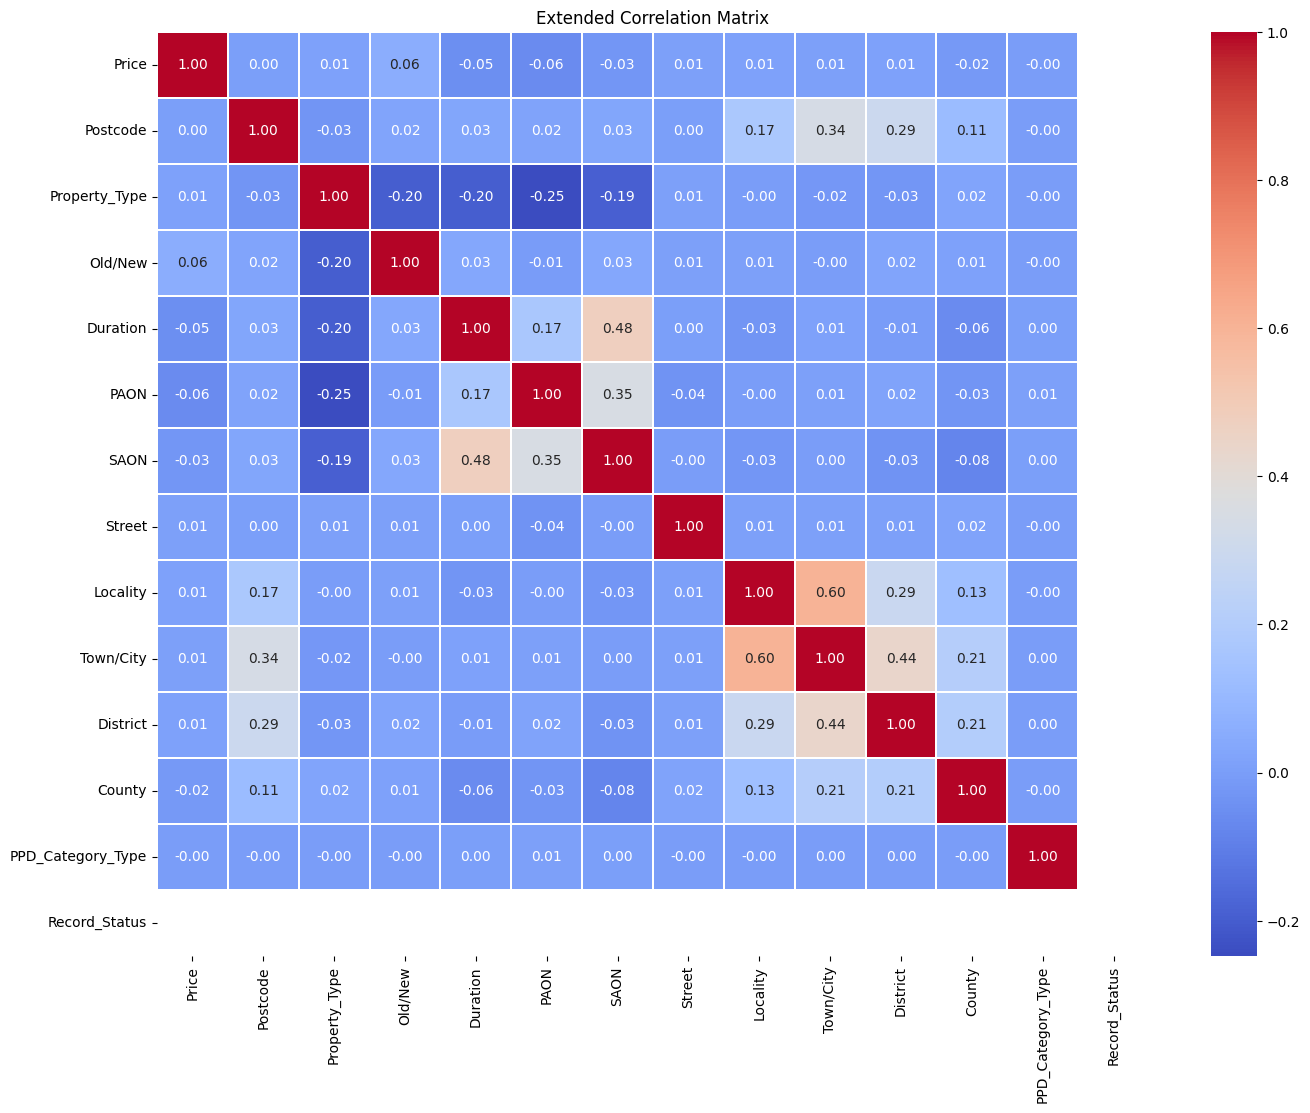

In [8]:
# Copy data
df_corr = df.copy()


# buang tanggal sementara
df_corr = df_corr.drop(
    columns=['Date_of_Transfer']
)


# encode semua object/category

for col in df_corr.columns:

    if df_corr[col].dtype == 'object':
        df_corr[col] = (
            df_corr[col]
            .astype('category')
            .cat.codes
        )


# correlation semua fitur

corr_matrix = df_corr.corr()


plt.figure(figsize=(16,12))


sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt=".2f",
    linewidths=0.3
)


plt.title(
    "Extended Correlation Matrix"
)

plt.show()

ReliefF

/tmp/ipykernel_314/323767946.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


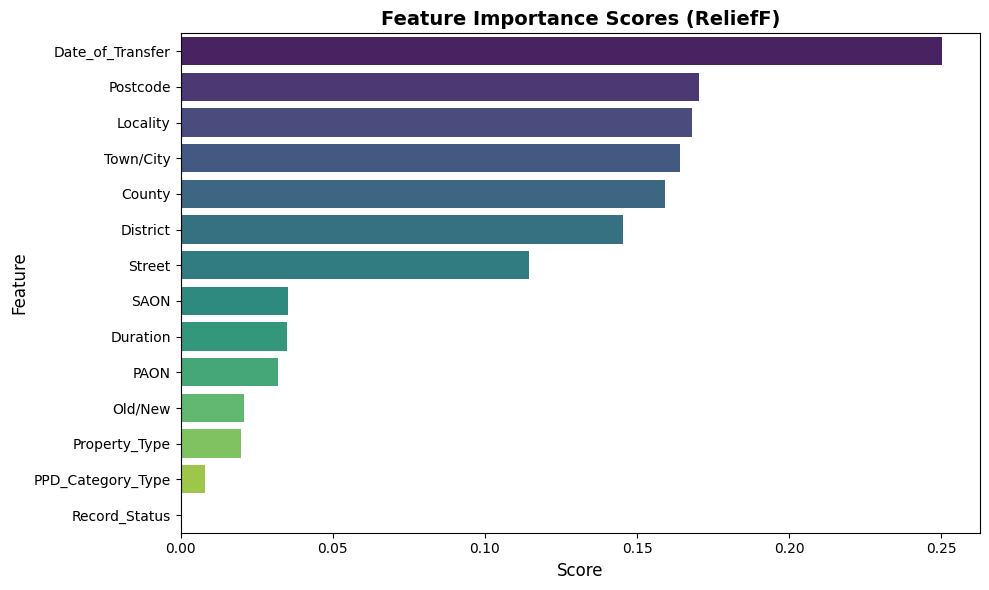

,Feature,Score
0,Date_of_Transfer,0.250161
1,Postcode,0.170280
8,Locality,0.168172
9,Town/City,0.164105
11,County,0.159203
10,District,0.145385
7,Street,0.114503
6,SAON,0.035277
4,Duration,0.035100
5,PAON,0.032046


In [11]:
df_relief = df.copy()

y = df_relief['Price'].astype('float32')
X = df_relief.drop(columns=['Price'])

for col in X.columns:
    X[col] = LabelEncoder().fit_transform(X[col].astype(str))
    X[col] = X[col].astype('float32')

sample_size = 5000 

X_sample = X.sample(sample_size, random_state=42)
y_sample = y.loc[X_sample.index]

del df_relief
gc.collect()

relief = ReliefF(
    n_neighbors=20, 
    n_features_to_select=X_sample.shape[1],
    n_jobs=-1
)

relief.fit(X_sample.values, y_sample.values)

result = pd.DataFrame({
    'Feature': X_sample.columns,
    'Score': relief.feature_importances_
})

result = result.sort_values(by='Score', ascending=False)

# --- TAMBAHAN VISUALISASI ---
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Score', 
    y='Feature', 
    data=result, 
    palette='viridis'
)
plt.title('Feature Importance Scores (ReliefF)', fontsize=14, fontweight='bold')
plt.xlabel('Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

# Menampilkan dataframe hasil
display(result)

In [12]:
columns = [
    'Price', 'Date_of_Transfer', 'Postcode', 'Property_Type',
    'Old/New', 'Duration', 'PAON', 'SAON', 'Street',
    'Locality', 'Town/City', 'District', 'County',
    'PPD_Category_Type', 'Record_Status'
]

# Gunakan usecols jika hanya ingin kolom tertentu, atau pastikan names sesuai jumlah kolom di file
# 1. Tentukan hanya kolom yang benar-benar memberikan nilai analisis
essential_cols = [
    'Price', 'Date_of_Transfer', 'Property_Type',
    'Old/New', 'Duration', 'Town/City', 'District', 'County'
]

# 2. Tentukan tipe data kategori untuk menghemat RAM (sangat efektif!)
dtype_opt = {
    'Property_Type': 'category',
    'Old/New': 'category',
    'Duration': 'category',
    'Town/City': 'category',
    'District': 'category',
    'County': 'category'
}

# 3. Load data (tanpa PAON, SAON, Street, Record_Status)
df = pd.read_csv(
    csv_file,
    names=columns,
    header=0,
    usecols=essential_cols,
    dtype=dtype_opt
)

print(df.head())
df.info()

   Price  Date_of_Transfer Property_Type Old/New Duration Town/City  \
0  25000  1995-03-31 00:00             F       N        L    LONDON   
1  25500  1995-05-17 00:00             F       N        L   ENFIELD   
2  42000  1995-04-21 00:00             T       N        L    LONDON   
3  43000  1995-06-30 00:00             T       N        F  DAGENHAM   
4   6500  1995-07-21 00:00             T       N        L   BURNLEY   

               District          County  
0                NEWHAM  GREATER LONDON  
1               ENFIELD  GREATER LONDON  
2               ENFIELD  GREATER LONDON  
3  BARKING AND DAGENHAM  GREATER LONDON  
4               BURNLEY      LANCASHIRE  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31270274 entries, 0 to 31270273
Data columns (total 8 columns):
 #   Column            Dtype   
---  ------            -----   
 0   Price             int64   
 1   Date_of_Transfer  object  
 2   Property_Type     category
 3   Old/New           category
 4   Duration  

### Correlation matrix

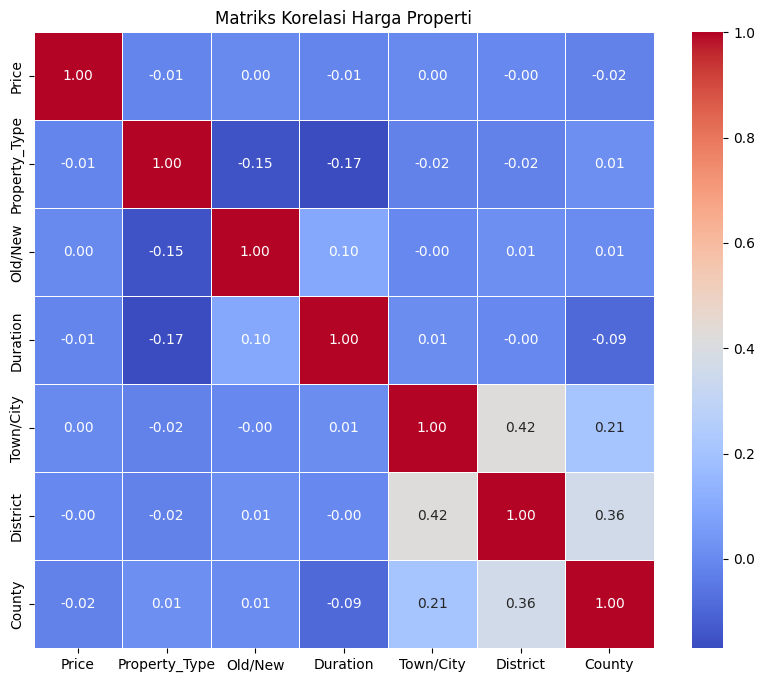

Urutan korelasi terhadap Price:
Price            1.000000
Town/City        0.002022
Old/New          0.001139
District        -0.002843
Property_Type   -0.010344
Duration        -0.012110
County          -0.022479
Name: Price, dtype: float64


In [ ]:
# 1. Buat salinan data agar data asli tidak rusak
df_korelasi = df.copy()

# 2. Ubah kolom kategori menjadi kode angka
kolom_kategori = ['Property_Type', 'Old/New', 'Duration', 'Town/City', 'District', 'County']
for kolom in kolom_kategori:
    df_korelasi[kolom] = df_korelasi[kolom].cat.codes

# 3. Hapus kolom tanggal sementara, lalu hitung korelasinya
matriks = df_korelasi.drop(columns=['Date_of_Transfer']).corr()

# 4. Gambar visualisasi Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(matriks, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi Harga Properti")
plt.show()

# 5. Tampilkan daftar urutan korelasi terhadap harga (Price)
print("Urutan korelasi terhadap Price:")
print(matriks['Price'].sort_values(ascending=False))

## Tren harga


Median Price per Year for Each Property Type:

--- Property Type: Detached ---


,Year,Price,Nama_Tipe
0,1995,86500.0,Detached
5,1996,89250.0,Detached
10,1997,95000.0,Detached
15,1998,103500.0,Detached
20,1999,115000.0,Detached
25,2000,127000.0,Detached
30,2001,141000.0,Detached
35,2002,169950.0,Detached
40,2003,199950.0,Detached
45,2004,230000.0,Detached



--- Property Type: Flats/Maisonettes ---


,Year,Price,Nama_Tipe
1,1995,46000.0,Flats/Maisonettes
6,1996,48000.0,Flats/Maisonettes
11,1997,53000.0,Flats/Maisonettes
16,1998,59000.0,Flats/Maisonettes
21,1999,67500.0,Flats/Maisonettes
26,2000,79000.0,Flats/Maisonettes
31,2001,90000.0,Flats/Maisonettes
36,2002,111000.0,Flats/Maisonettes
41,2003,126750.0,Flats/Maisonettes
46,2004,142000.0,Flats/Maisonettes



--- Property Type: Semi-Detached ---


,Year,Price,Nama_Tipe
2,1995,53000.0,Semi-Detached
7,1996,54500.0,Semi-Detached
12,1997,57995.0,Semi-Detached
17,1998,59995.0,Semi-Detached
22,1999,65952.0,Semi-Detached
27,2000,72000.0,Semi-Detached
32,2001,81500.0,Semi-Detached
37,2002,97500.0,Semi-Detached
42,2003,123000.0,Semi-Detached
47,2004,144500.0,Semi-Detached



--- Property Type: Terraced ---


,Year,Price,Nama_Tipe
3,1995,42750.0,Terraced
8,1996,44000.0,Terraced
13,1997,47500.0,Terraced
18,1998,50000.0,Terraced
23,1999,56000.0,Terraced
28,2000,59995.0,Terraced
33,2001,68950.0,Terraced
38,2002,80450.0,Terraced
43,2003,95000.0,Terraced
48,2004,118000.0,Terraced



--- Property Type: Other ---


,Year,Price,Nama_Tipe
4,1995,10000.0,Other
9,1996,728.5,Other
14,1997,95000.0,Other
19,1998,47750.0,Other
24,1999,6697.5,Other
29,2000,38750.0,Other
34,2001,60000.0,Other
39,2002,24250.0,Other
44,2003,73000.0,Other
49,2004,48769.0,Other


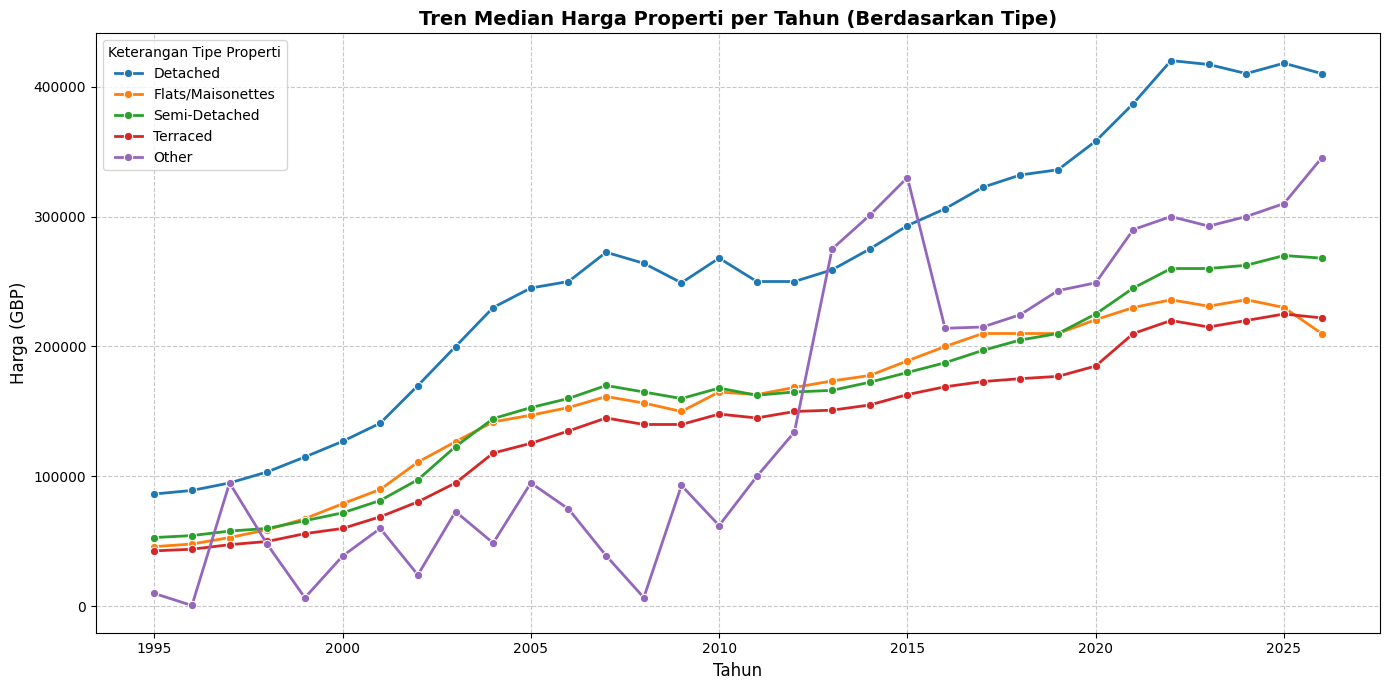

In [ ]:
# 1. Buat kamus (dictionary) terjemahan singkatan ke nama lengkap
nama_tipe_properti = {
    'D': 'Detached',
    'S': 'Semi-Detached',
    'T': 'Terraced',
    'F': 'Flats/Maisonettes',
    'O': 'Other'
}

# Ensure 'Date_of_Transfer' is datetime and extract 'Year'
df['Date_of_Transfer'] = pd.to_datetime(df['Date_of_Transfer'])
df['Year'] = df['Date_of_Transfer'].dt.year

# 2. Hitung median harga seperti kode sebelumnya
yearly_type_price = df.groupby(['Year', 'Property_Type'], observed=True)['Price'].median().reset_index()

# 3. Terjemahkan kolom Property_Type menggunakan kamus yang sudah dibuat
# Kita membuat kolom baru agar tidak merusak data aslinya
yearly_type_price['Nama_Tipe'] = yearly_type_price['Property_Type'].map(nama_tipe_properti)

# Print separate tables for each property type
print("\nMedian Price per Year for Each Property Type:")
for prop_type in yearly_type_price['Nama_Tipe'].unique():
    print(f"\n--- Property Type: {prop_type} ---")
    display(yearly_type_price[yearly_type_price['Nama_Tipe'] == prop_type].drop(columns=['Property_Type']))

# 4. Buat grafik, perhatikan bahwa 'hue' sekarang menggunakan kolom 'Nama_Tipe'
plt.figure(figsize=(14, 7))
sns.lineplot(data=yearly_type_price, x='Year', y='Price', hue='Nama_Tipe', marker='o', linewidth=2)

plt.title('Tren Median Harga Properti per Tahun (Berdasarkan Tipe)', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga (GBP)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Ubah judul legend agar lebih rapi
plt.legend(title='Keterangan Tipe Properti')
plt.tight_layout()
plt.show()

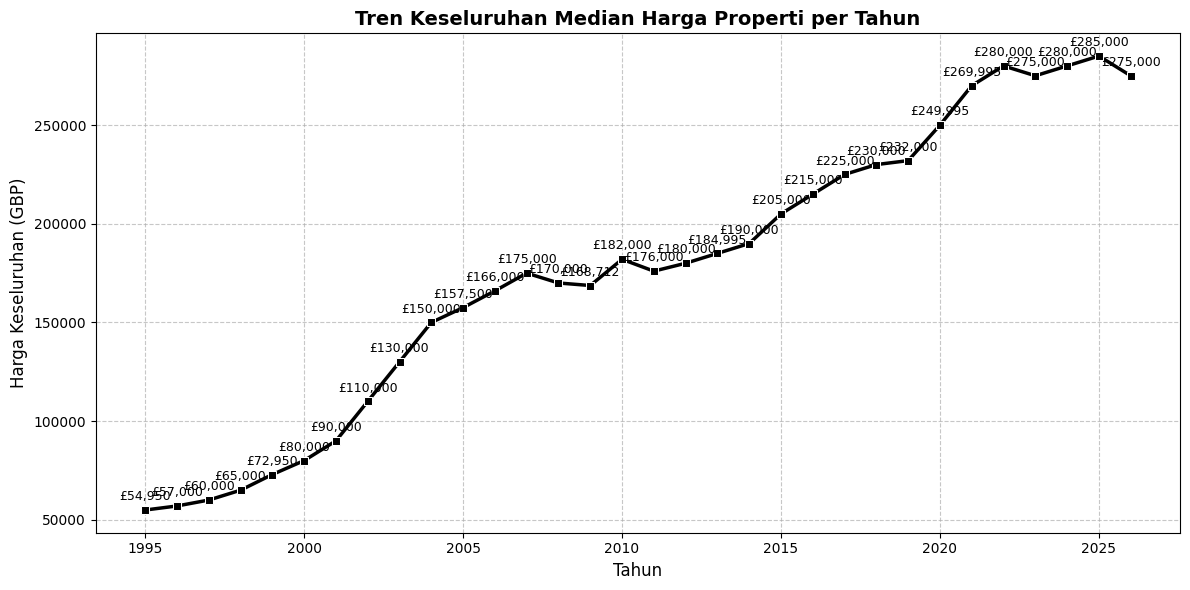

In [ ]:
# =====================================================================
# VISUALISASI 2: Tren Harga Keseluruhan (Overall)
# =====================================================================
# Kelompokkan data hanya berdasarkan Tahun
yearly_overall_price = df.groupby('Year')['Price'].median().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_overall_price, x='Year', y='Price', color='black', marker='s', linewidth=2.5)

plt.title('Tren Keseluruhan Median Harga Properti per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Harga Keseluruhan (GBP)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Opsional: Menambahkan angka di setiap titik untuk membaca tren dengan lebih mudah
for i in range(yearly_overall_price.shape[0]):
    plt.text(yearly_overall_price['Year'].iloc[i],
             yearly_overall_price['Price'].iloc[i] + 5000,
             f"£{int(yearly_overall_price['Price'].iloc[i]):,}",
             ha='center', fontsize=9)

plt.tight_layout()
plt.show()

/tmp/ipykernel_11932/2442208815.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tabel_distribusi_county = data_tahunan.groupby('County')['Jumlah_Transaksi'].sum().reset_index()
/tmp/ipykernel_11932/2442208815.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_counties, x='Jumlah_Transaksi', y='County', palette='magma')


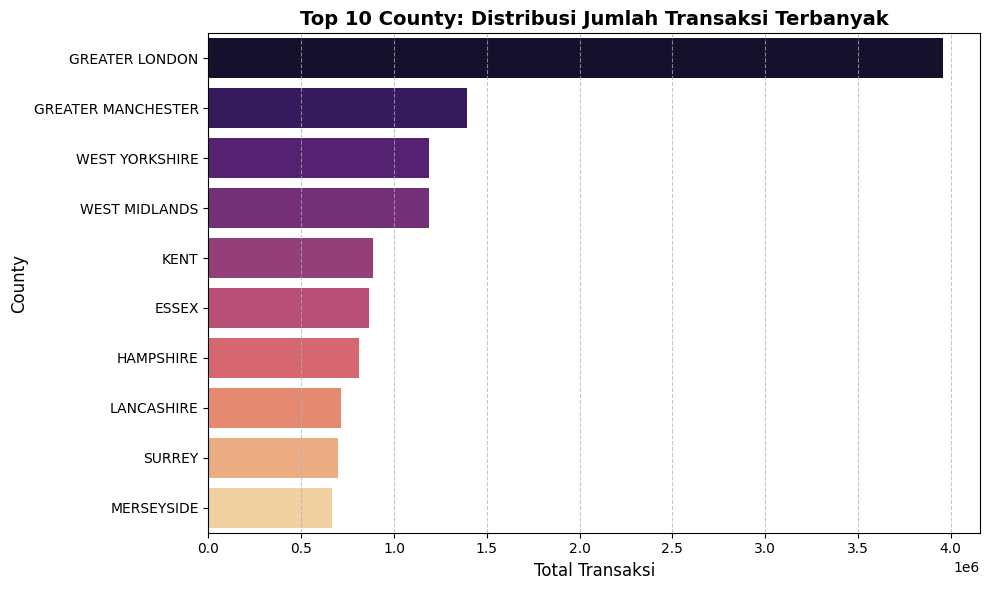

In [ ]:
# Lakukan perhitungan dari DataFrame asli HANYA SEKALI
# Ini langsung mengubah jutaan baris menjadi tabel rekap kecil (beberapa ratus baris)
data_tahunan = df.groupby(['Year', 'County'], observed=True)['Price'].count().reset_index()
data_tahunan.rename(columns={'Price': 'Jumlah_Transaksi'}, inplace=True)

# Calculate the total transactions per county
tabel_distribusi_county = data_tahunan.groupby('County')['Jumlah_Transaksi'].sum().reset_index()
tabel_distribusi_county = tabel_distribusi_county.sort_values(by='Jumlah_Transaksi', ascending=False)

top_10_counties = tabel_distribusi_county.head(10).copy()

# 2. INI KUNCI PERBAIKANNYA: Ubah kolom kembali ke teks biasa
# agar Seaborn melupakan memori ratusan nama County lainnya
top_10_counties['County'] = top_10_counties['County'].astype(str)

plt.figure(figsize=(10, 6))
# Membuat bar chart horizontal
sns.barplot(data=top_10_counties, x='Jumlah_Transaksi', y='County', palette='magma')

plt.title('Top 10 County: Distribusi Jumlah Transaksi Terbanyak', fontsize=14, fontweight='bold')
plt.xlabel('Total Transaksi', fontsize=12)
plt.ylabel('County', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


TABEL PERTUMBUHAN HARGA: GREATER LONDON
 Year    Price
 2017 450000.0
 2018 450000.0
 2019 455000.0
 2020 480557.0
 2021 492000.0
 2022 514000.0
 2023 510000.0
 2024 511000.0
 2025 510000.0
 2026 487850.0


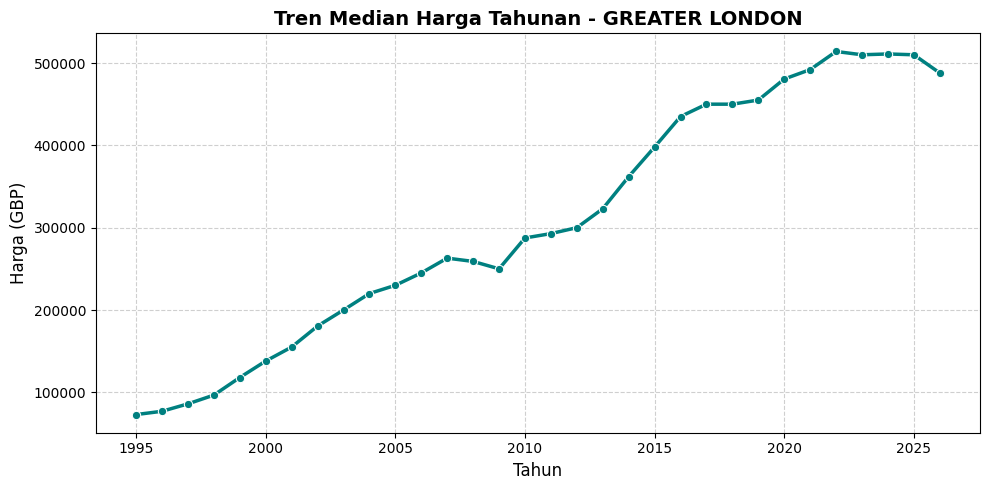


TABEL PERTUMBUHAN HARGA: GREATER MANCHESTER
 Year    Price
 2017 150000.0
 2018 158000.0
 2019 163250.0
 2020 178000.0
 2021 196000.0
 2022 210000.0
 2023 210000.0
 2024 220000.0
 2025 229500.0
 2026 225923.0


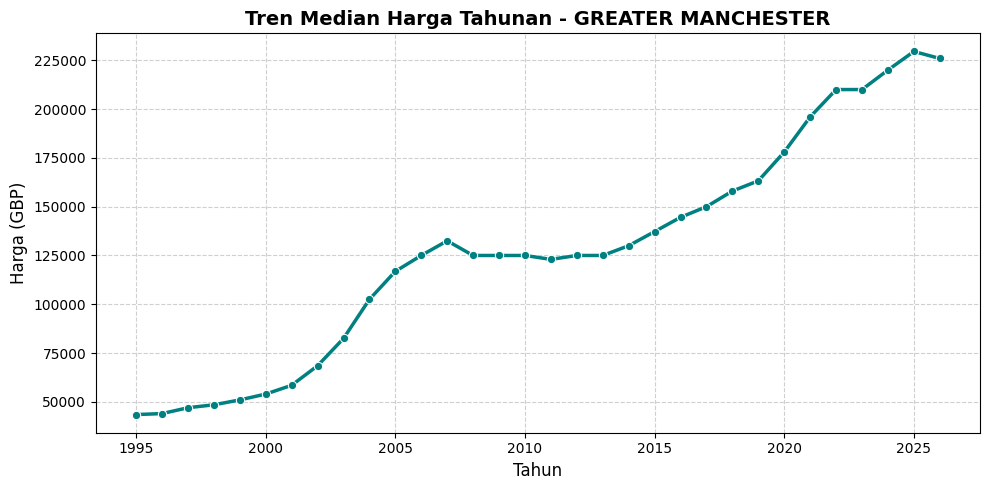


TABEL PERTUMBUHAN HARGA: WEST YORKSHIRE
 Year    Price
 2017 145000.0
 2018 152000.0
 2019 157500.0
 2020 164500.0
 2021 176000.0
 2022 187000.0
 2023 187000.0
 2024 196870.0
 2025 205000.0
 2026 203000.0


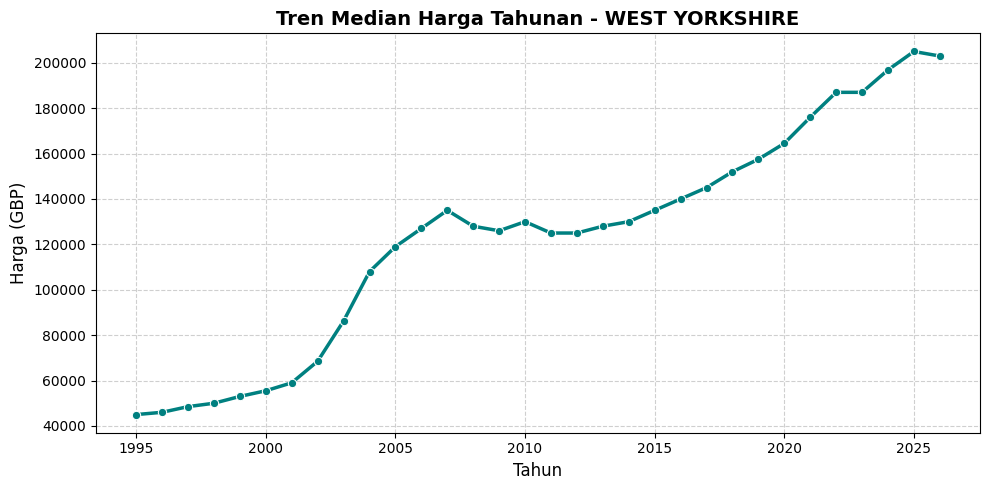


TABEL PERTUMBUHAN HARGA: WEST MIDLANDS
 Year    Price
 2017 160000.0
 2018 170000.0
 2019 174950.0
 2020 182952.0
 2021 200000.0
 2022 215000.0
 2023 216000.0
 2024 220000.0
 2025 228000.0
 2026 228000.0


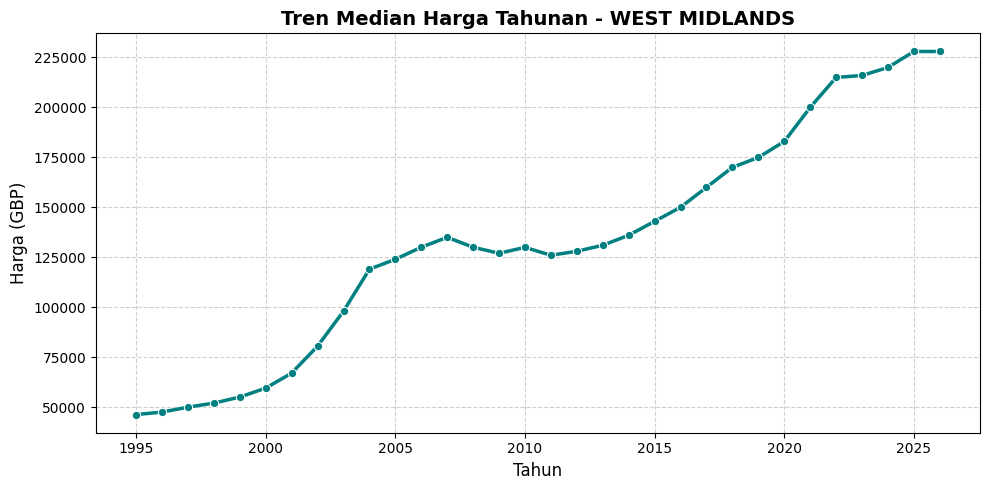


TABEL PERTUMBUHAN HARGA: KENT
 Year    Price
 2017 277000.0
 2018 287950.0
 2019 290000.0
 2020 308000.0
 2021 330000.0
 2022 350000.0
 2023 340000.0
 2024 335000.0
 2025 343000.0
 2026 330000.0


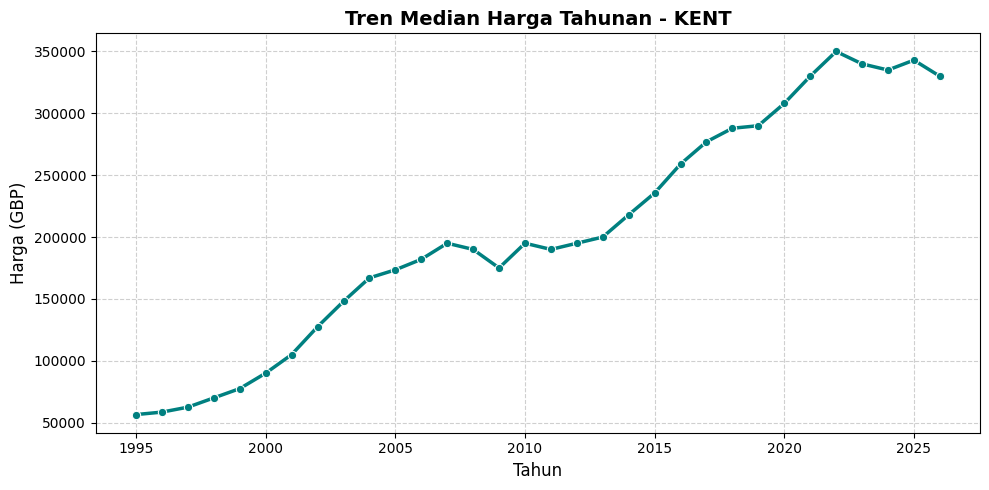


TABEL PERTUMBUHAN HARGA: ESSEX
 Year    Price
 2017 300000.0
 2018 309995.0
 2019 309950.0
 2020 325000.0
 2021 340000.0
 2022 365000.0
 2023 355000.0
 2024 360000.0
 2025 370000.0
 2026 350000.0


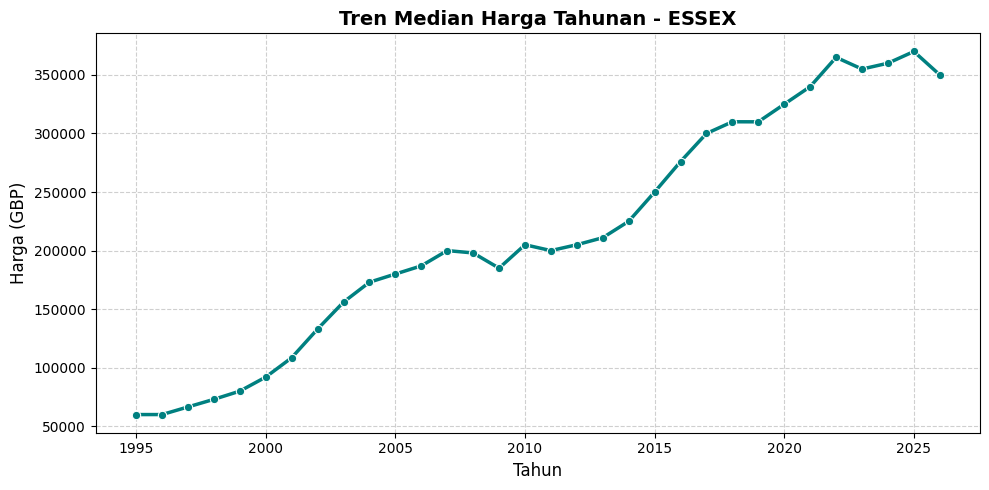


TABEL PERTUMBUHAN HARGA: HAMPSHIRE
 Year    Price
 2017 305000.0
 2018 310000.0
 2019 312000.0
 2020 329995.0
 2021 345000.0
 2022 370000.0
 2023 360000.0
 2024 365000.0
 2025 365000.0
 2026 355000.0


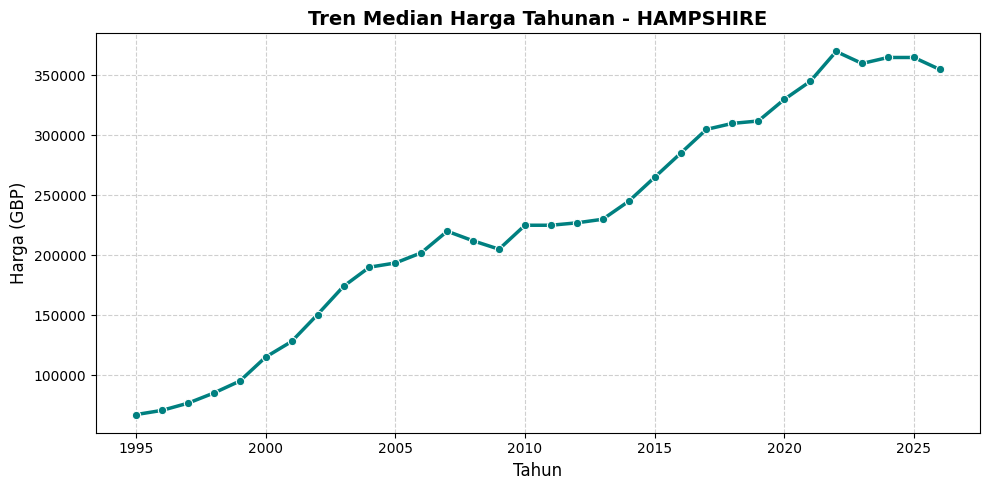


TABEL PERTUMBUHAN HARGA: LANCASHIRE
 Year    Price
 2017 145001.0
 2018 146500.0
 2019 150000.0
 2020 160000.0
 2021 172500.0
 2022 179950.0
 2023 180000.0
 2024 185000.0
 2025 190000.0
 2026 182500.0


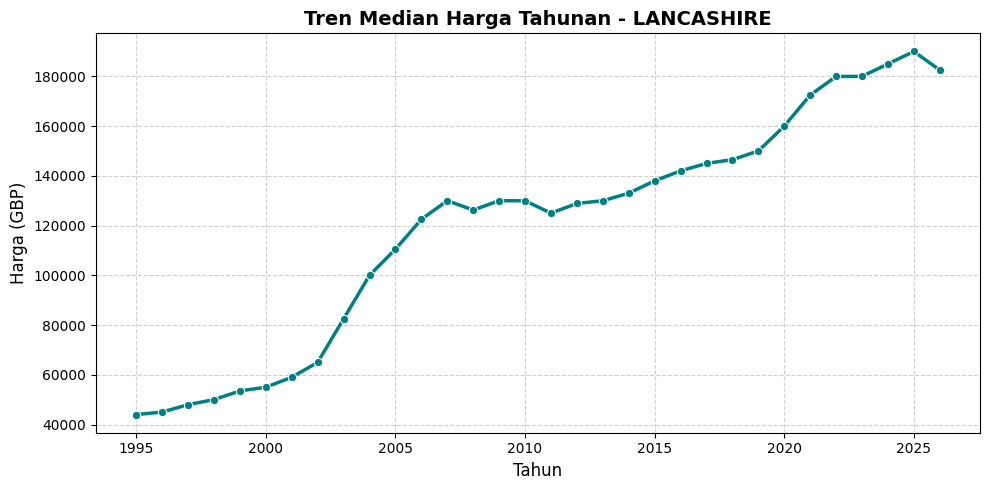


TABEL PERTUMBUHAN HARGA: SURREY
 Year    Price
 2017 423125.0
 2018 425000.0
 2019 425000.0
 2020 460000.0
 2021 470000.0
 2022 490000.0
 2023 490000.0
 2024 487500.0
 2025 497500.0
 2026 480000.0


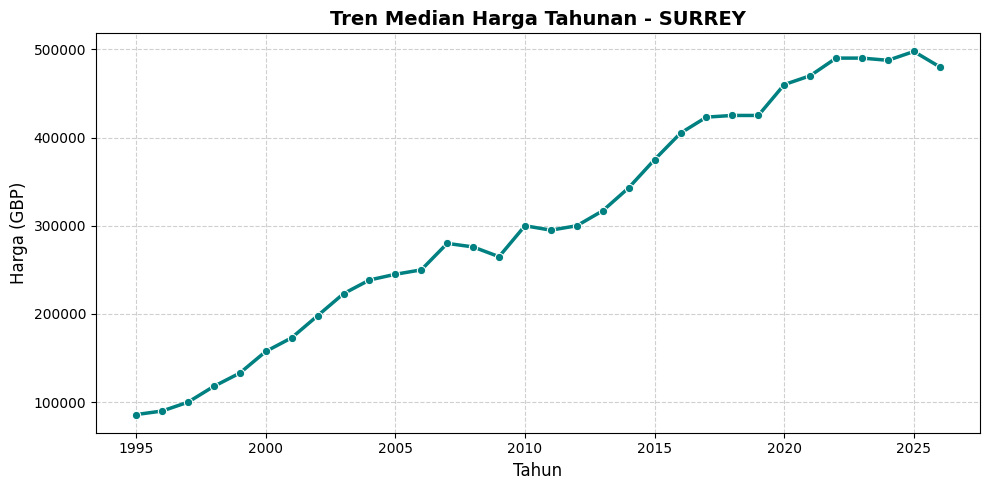


TABEL PERTUMBUHAN HARGA: MERSEYSIDE
 Year    Price
 2017 135000.0
 2018 135000.0
 2019 139950.0
 2020 149650.0
 2021 164995.0
 2022 170000.0
 2023 170000.0
 2024 180000.0
 2025 187500.0
 2026 188000.0


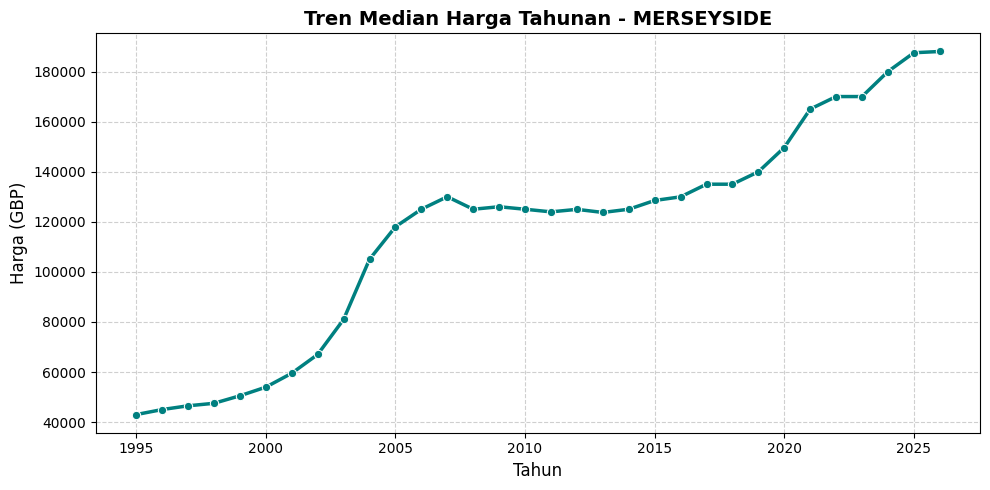

In [ ]:
# Ambil daftar nama 10 County teratas menjadi bentuk list (daftar)
list_top_counties = top_10_counties['County'].tolist()

# Lakukan perulangan untuk setiap wilayah di dalam daftar Top 10
for wilayah in list_top_counties:

    # 1. Filter data HANYA untuk wilayah yang sedang di-looping saat ini
    df_wilayah = df[df['County'] == wilayah]

    # 2. Hitung median harga dari tahun ke tahun untuk wilayah ini
    pertumbuhan_tahunan = df_wilayah.groupby('Year', observed=True)['Price'].median().reset_index()

    # 3. TAMPILKAN TABEL (Tampilkan 5 tahun terbaru agar output tidak terlalu panjang di terminal)
    print(f"\n{'='*50}")
    print(f"TABEL PERTUMBUHAN HARGA: {wilayah}")
    print(f"{'='*50}")
    print(pertumbuhan_tahunan.tail(10).to_string(index=False)) # .tail(5) mengambil data paling baru

    # 4. TAMPILKAN GRAFIK
    plt.figure(figsize=(10, 5))
    sns.lineplot(
        data=pertumbuhan_tahunan,
        x='Year',
        y='Price',
        marker='o',
        color='teal',
        linewidth=2.5
    )

    plt.title(f"Tren Median Harga Tahunan - {wilayah}", fontsize=14, fontweight='bold')
    plt.xlabel("Tahun", fontsize=12)
    plt.ylabel("Harga (GBP)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Format sumbu Y agar tidak pakai notasi ilmiah (e.g., 1e6)
    plt.ticklabel_format(style='plain', axis='y')

    plt.tight_layout()
    plt.show()

## Distribusi data

TABEL DISTRIBUSI PROPERTI TERJUAL
 Tahun  Jumlah_Properti_Terjual
  1995                   797132
  1996                   965399
  1997                  1094625
  1998                  1050670
  1999                  1195046
  2000                  1129549
  2001                  1246006
  2002                  1351939
  2003                  1235619
  2004                  1232143
  2005                  1061795
  2006                  1326239
  2007                  1272470
  2008                   649709
  2009                   625364
  2010                   663338
  2011                   661251
  2012                   668966
  2013                   811157
  2014                   985174
  2015                  1011674
  2016                  1046356
  2017                  1067555
  2018                  1037574
  2019                  1012069
  2020                   897344
  2021                  1281284
  2022                  1076231
  2023                   860330
  2024

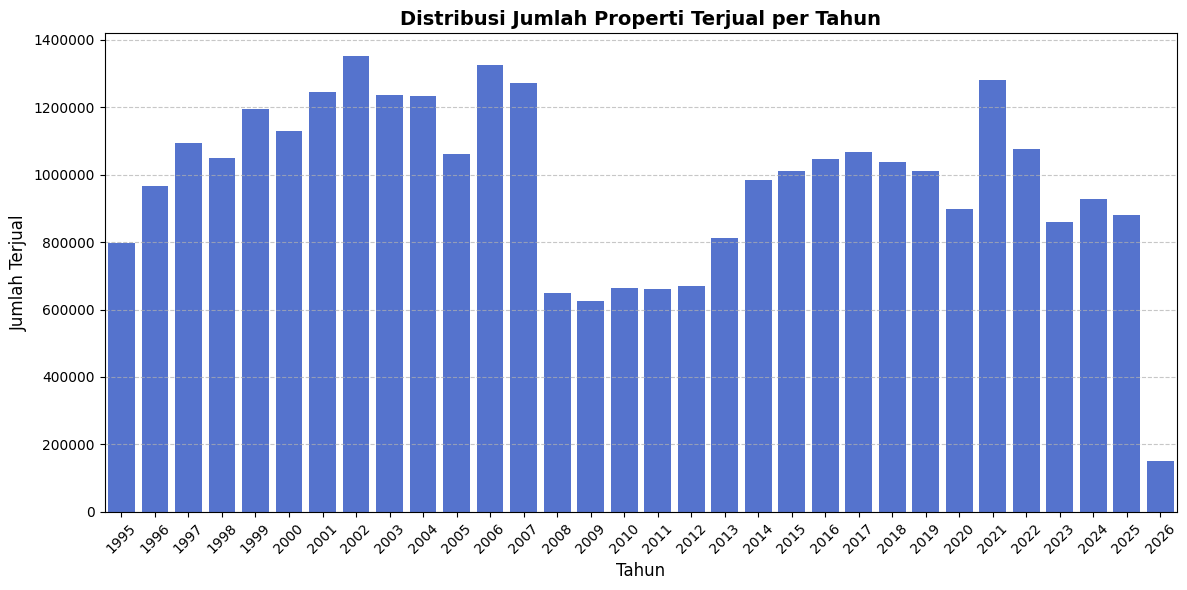

In [ ]:
# 1. Membuat Tabel Distribusi Transaksi Tahunan
# Mengelompokkan berdasarkan kolom 'Year' dan menghitung jumlah kemunculan harganya
tabel_transaksi_tahunan = df.groupby('Year', observed=True)['Price'].count().reset_index()

# Mengubah nama kolom agar mudah dibaca saat dicetak
tabel_transaksi_tahunan.columns = ['Tahun', 'Jumlah_Properti_Terjual']

# Menampilkan tabel
print("="*40)
print("TABEL DISTRIBUSI PROPERTI TERJUAL")
print("="*40)
print(tabel_transaksi_tahunan.to_string(index=False))

# 2. Membuat Visualisasi Grafik (Bar Chart)
plt.figure(figsize=(12, 6))

# Menggunakan diagram batang untuk melihat perbandingan volume tiap tahun
sns.barplot(
    data=tabel_transaksi_tahunan,
    x='Tahun',
    y='Jumlah_Properti_Terjual',
    color='royalblue'
)

plt.title('Distribusi Jumlah Properti Terjual per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Terjual', fontsize=12)

# Memutar teks tahun sebesar 45 derajat agar tidak saling tumpang tindih
plt.xticks(rotation=45)

# Format sumbu Y agar angkanya dibaca normal (contoh: 1000000), bukan notasi ilmiah (1e6)
plt.ticklabel_format(style='plain', axis='y')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Tren Volume Penjualan

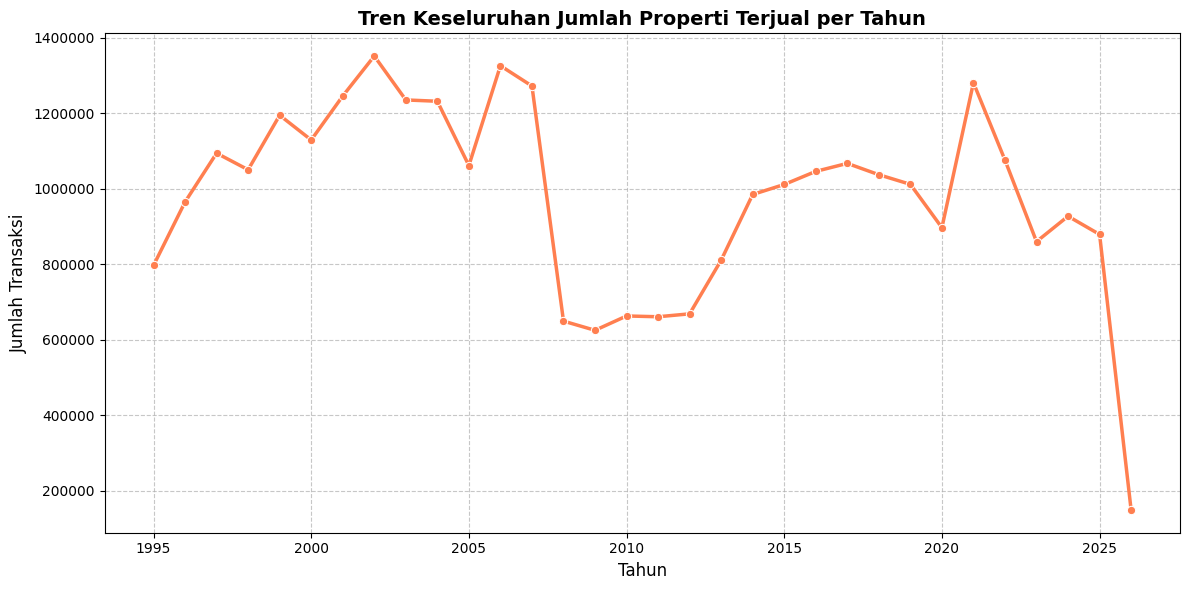

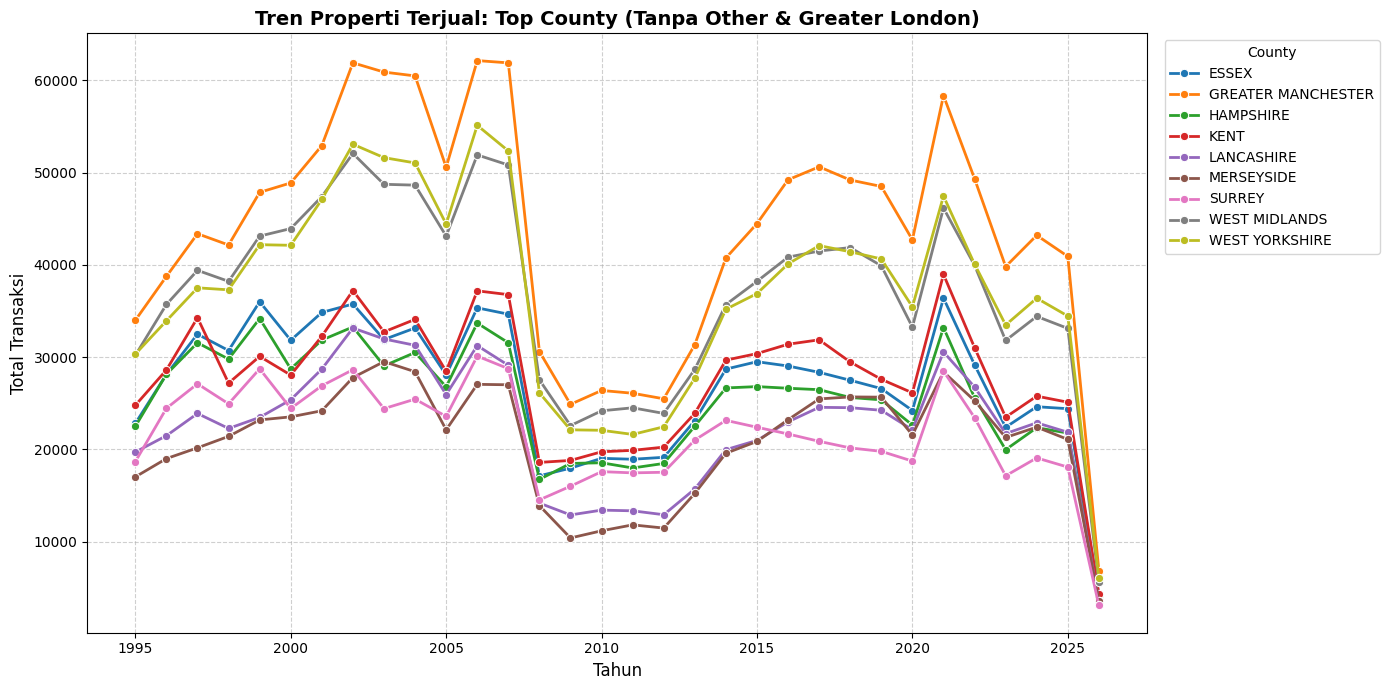

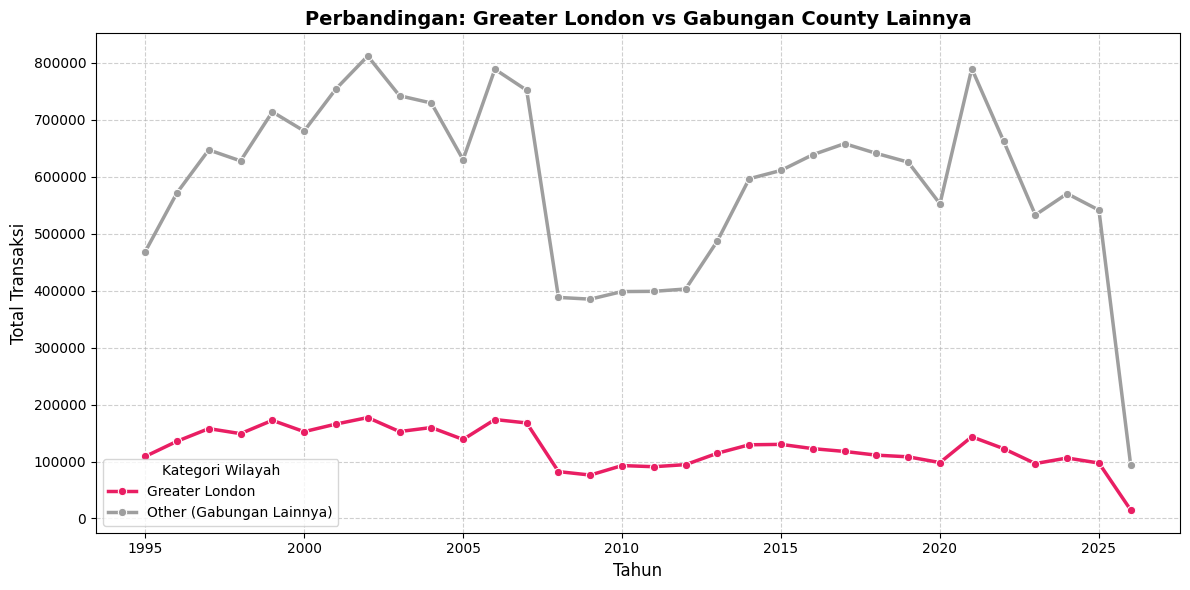


CATATAN ANALISIS:
- Grafik A: Memperlihatkan persaingan antar county tanpa gangguan outlier volume tinggi.
- Grafik B: Greater London dipisah dari 'Other' agar tren dominasinya bisa dibaca sendiri.
  County yang masuk 'Other' adalah semua county di luar Top 10 dan bukan Greater London.



In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# ==============================================================================
# 1. TAHAP PEMROSESAN DATA (Dioptimasi)
# ==============================================================================



# A. Data untuk Grafik Keseluruhan (Overall)
# Daripada menghitung ulang df asli, kita cukup menjumlahkan hasil rekap di atas
tabel_transaksi_tahunan = data_tahunan.groupby('Year')['Jumlah_Transaksi'].sum().reset_index()

# B. Data untuk Grafik Top 10 vs Other
list_top_10 = top_10_counties['County'].tolist()
data_tahunan['Kategori_Wilayah'] = np.where(
    data_tahunan['County'].isin(list_top_10),
    data_tahunan['County'].astype(str),
    'OTHER (Gabungan)'
)
tren_gabungan = data_tahunan.groupby(['Year', 'Kategori_Wilayah'])['Jumlah_Transaksi'].sum().reset_index()

# ==============================================================================
# 2. TAHAP VISUALISASI
# ==============================================================================

# Grafik 1: Tren Keseluruhan
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=tabel_transaksi_tahunan,
    x='Year',
    y='Jumlah_Transaksi',
    color='coral',
    marker='o',
    linewidth=2.5
)
plt.title('Tren Keseluruhan Jumlah Properti Terjual per Tahun', fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Jumlah Transaksi', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Grafik 2

GREATER_LONDON_KEYWORDS = ['GREATER LONDON']

# Kategorikan tiap county ke dalam 3 grup
def kategorikan(county):
    county_upper = str(county).upper()
    if any(kw in county_upper for kw in GREATER_LONDON_KEYWORDS):
        return 'Greater London'
    elif county in list_top_10:
        return str(county)
    else:
        return 'Other (Gabungan Lainnya)'

data_tahunan['Kategori_Wilayah'] = data_tahunan['County'].apply(kategorikan)
tren_gabungan = data_tahunan.groupby(['Year', 'Kategori_Wilayah'])['Jumlah_Transaksi'].sum().reset_index()

# --- GRAFIK A: Top County TANPA Other & tanpa Greater London ---
kategori_exclude = ['Other (Gabungan Lainnya)', 'Greater London']
tren_top_only = tren_gabungan[~tren_gabungan['Kategori_Wilayah'].isin(kategori_exclude)]

plt.figure(figsize=(14, 7))
sns.lineplot(
    data=tren_top_only,
    x='Year', y='Jumlah_Transaksi',
    hue='Kategori_Wilayah',
    marker='o', linewidth=2, palette='tab10'
)
plt.title('Tren Properti Terjual: Top County (Tanpa Other & Greater London)',
          fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Transaksi', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='County', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

# --- GRAFIK B: Greater London vs Other (Gabungan) ---
tren_london_other = tren_gabungan[tren_gabungan['Kategori_Wilayah'].isin(['Greater London', 'Other (Gabungan Lainnya)'])]

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=tren_london_other,
    x='Year', y='Jumlah_Transaksi',
    hue='Kategori_Wilayah',
    marker='o', linewidth=2.5,
    palette={'Greater London': '#E91E63', 'Other (Gabungan Lainnya)': '#9E9E9E'}
)
plt.title('Perbandingan: Greater London vs Gabungan County Lainnya',
          fontsize=14, fontweight='bold')
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Transaksi', fontsize=12)
plt.ticklabel_format(style='plain', axis='y')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Kategori Wilayah')
plt.tight_layout()
plt.show()

print("""
CATATAN ANALISIS:
- Grafik A: Memperlihatkan persaingan antar county tanpa gangguan outlier volume tinggi.
- Grafik B: Greater London dipisah dari 'Other' agar tren dominasinya bisa dibaca sendiri.
  County yang masuk 'Other' adalah semua county di luar Top 10 dan bukan Greater London.
""")


Distribusi Jumlah Properti Lama vs Baru:
Old/New    Count
      N 28000091
      Y  3270183


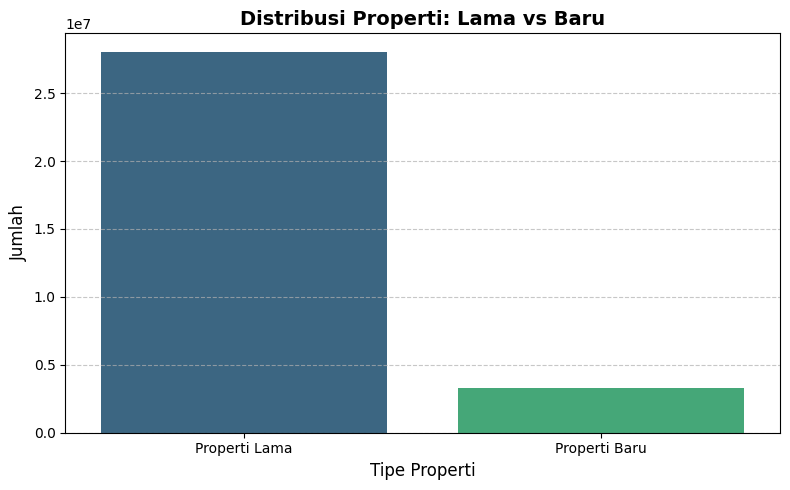

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate distribution for 'Old/New'
old_new_dist = df['Old/New'].value_counts().reset_index()
old_new_dist.columns = ['Old/New', 'Count']

# Print the table for specific numbers of old/new properties
print("\nDistribusi Jumlah Properti Lama vs Baru:")
print(old_new_dist.to_string(index=False))

plt.figure(figsize=(8, 5))
sns.barplot(data=old_new_dist, x='Old/New', y='Count', hue='Old/New', palette='viridis', legend=False)
plt.title('Distribusi Properti: Lama vs Baru', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Properti', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.xticks(ticks=[0, 1], labels=['Properti Lama', 'Properti Baru']) # Corrected labels
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


Distribusi Jumlah Properti Berdasarkan Tipe:
Property_Type_Name   Count
          Terraced 9265608
     Semi-Detached 8531718
          Detached 7208376
 Flats/Maisonettes 5629190
             Other  635382


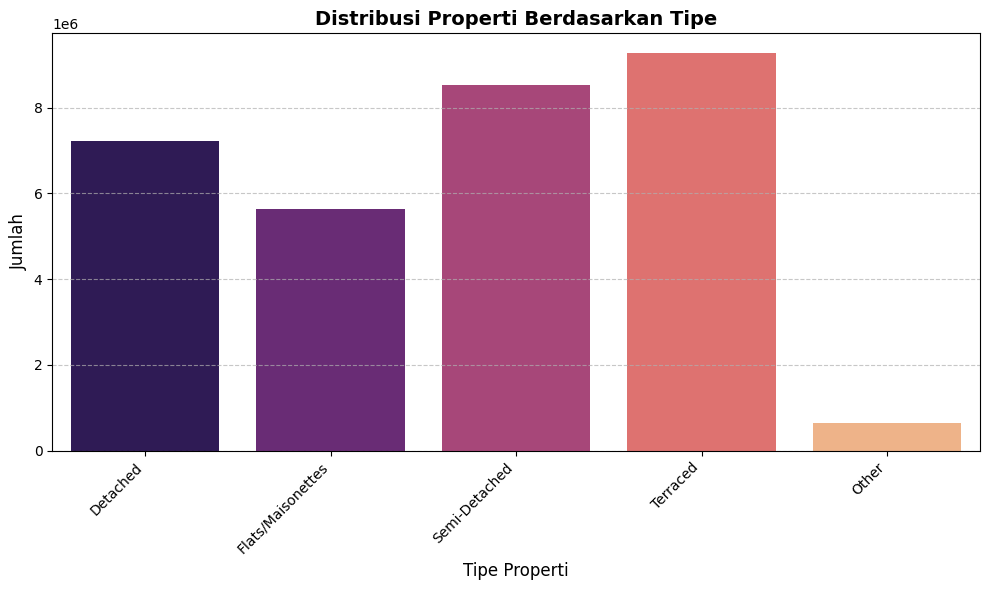

In [ ]:
# 1. Buat kamus (dictionary) terjemahan singkatan ke nama lengkap (reusing from previous cell -DtPxwCkAs0_)
nama_tipe_properti = {
    'D': 'Detached',
    'S': 'Semi-Detached',
    'T': 'Terraced',
    'F': 'Flats/Maisonettes',
    'O': 'Other'
}

# Calculate distribution for 'Property_Type'
property_type_dist = df['Property_Type'].value_counts().reset_index()
property_type_dist.columns = ['Property_Type_Code', 'Count']

# Map codes to full names for better readability on the plot
property_type_dist['Property_Type_Name'] = property_type_dist['Property_Type_Code'].map(nama_tipe_properti)

# Print the table for specific numbers of each property type
print("\nDistribusi Jumlah Properti Berdasarkan Tipe:")
print(property_type_dist[['Property_Type_Name', 'Count']].to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(data=property_type_dist, x='Property_Type_Name', y='Count', legend=False)
plt.title('Distribusi Properti Berdasarkan Tipe', fontsize=14, fontweight='bold')
plt.xlabel('Tipe Properti', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Pemodelan ML

In [ ]:
# Import library yang dibutuhkan untuk tahap selanjutnya
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
import numpy as np
import time

print("Mulai tahap Data Pre-processing...")
# 1. Menyiapkan Data (Mengambil data df dari tahap sebelumnya)
df_model = df.copy()

# Pastikan kita punya kolom 'Year' untuk model prediksi (jika terlewat di tahap sebelumnya)
if 'Year' not in df_model.columns and 'Date_of_Transfer' in df_model.columns:
    df_model['Date_of_Transfer'] = pd.to_datetime(df_model['Date_of_Transfer'])
    df_model['Year'] = df_model['Date_of_Transfer'].dt.year

# Hapus kolom tanggal asli karena model ML (RF & XGBoost) hanya menerima angka
if 'Date_of_Transfer' in df_model.columns:
    df_model = df_model.drop(columns=['Date_of_Transfer'])

# Hapus missing values jika ada (Data Cleaning lanjutan)
df_model = df_model.dropna()

# 2. Encoding untuk variabel kategorik
# Kita hanya melakukan encoding pada kolom yang masih tersisa
kolom_kategori = ['Property_Type', 'Old/New', 'Duration', 'Town/City', 'District', 'County']
le = LabelEncoder()

for col in kolom_kategori:
    if col in df_model.columns:
        # Ubah ke string dulu untuk menghindari error jika ada tipe data campuran
        df_model[col] = le.fit_transform(df_model[col].astype(str))

# 3. Memisahkan Fitur (X) dan Target (y)
X = df_model.drop(columns=['Price'])
y = df_model['Price']

# 4. Train-Test Split (Membagi data training 80% dan testing 20%)
# Menggunakan semua data secara penuh (full dataset)
print("Membagi data menjadi training dan testing...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Pemodelan Machine Learning (Tanpa Scaling)
print("Mulai melatih model (Ini mungkin memakan waktu untuk data besar)...")

# Menggunakan n_jobs=-1 agar memproses menggunakan semua inti CPU (CPU cores)
# n_estimators diatur ke 50 dulu agar prosesnya tidak terlalu lama/berat di memori.
rf_model = RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=10, random_state=42, n_jobs=-1)

# Training Model (Langsung menggunakan X_train)
start_time = time.time()
rf_model.fit(X_train, y_train)
print(f"Random Forest selesai dilatih dalam {time.time() - start_time:.2f} detik")

start_time = time.time()
xgb_model.fit(X_train, y_train)
print(f"XGBoost selesai dilatih dalam {time.time() - start_time:.2f} detik")

# 6. Proses Prediksi Independen (Langsung menggunakan X_test)
print("Menghitung prediksi...")
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

# 7. Metode Ansambel (Ensemble) - Menghitung rata-rata dari kedua model
final_pred = (rf_pred + xgb_pred) / 2

# 8. Evaluasi Model (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, final_pred))

print("\n" + "="*40)
print(f"NILAI EVALUASI AKHIR (RMSE): £{rmse:,.2f}")
print("="*40)

Mulai tahap Data Pre-processing...
Membagi data menjadi training dan testing...
Mulai melatih model (Ini mungkin memakan waktu untuk data besar)...
Random Forest selesai dilatih dalam 1342.00 detik
XGBoost selesai dilatih dalam 50.27 detik
Menghitung prediksi...

NILAI EVALUASI AKHIR (RMSE): £920,879.81


In [ ]:
import pandas as pd
import numpy as np

print("Menampilkan Perbandingan Harga Asli vs Prediksi (10 Data Terakhir)...")

# Membuat DataFrame langsung dari variabel yang sudah ada di memori Colab
comparison_df = pd.DataFrame({
    'Harga Asli (£)': y_test.values,
    'Tebakan Model (£)': final_pred,
    'Selisih Error (£)': np.abs(y_test.values - final_pred)
})

# Mengambil 10 baris paling bawah (terakhir)
last_10_comparison = comparison_df.tail(10)

# Menampilkan tabel dengan format angka yang rapi (menggunakan koma)
print("-" * 60)
print(last_10_comparison.to_string(index=False, float_format=lambda x: "{:,.2f}".format(x)))
print("-" * 60)

Menampilkan Perbandingan Harga Asli vs Prediksi (10 Data Terakhir)...
------------------------------------------------------------
 Harga Asli (£)  Tebakan Model (£)  Selisih Error (£)
         246000         217,930.20          28,069.80
         123500         173,090.62          49,590.62
          63000          52,182.20          10,817.80
          95000         151,043.51          56,043.51
        4500000         643,019.08       3,856,980.92
         242000         227,489.90          14,510.10
         540000         323,426.57         216,573.43
         370000         396,872.75          26,872.75
         245000         211,536.00          33,464.00
          55000          79,344.83          24,344.83
------------------------------------------------------------
